In [1]:
import requests
import pandas as pd
import time
import os
from dotenv import load_dotenv

load_dotenv()
print("Libraries loaded!")

Libraries loaded!


In [2]:
API_KEY = os.getenv("RAPIDAPI_KEY")
print("Key found:", API_KEY[:8] + "..." if API_KEY else "NOT FOUND")

Key found: fca2446c...


In [6]:
def scrape_jobs(query, num_pages=5):
    all_jobs = []
    
    url = "https://jsearch.p.rapidapi.com/search"
    headers = {
        "X-RapidAPI-Key": os.getenv("RAPIDAPI_KEY"),
        "X-RapidAPI-Host": "jsearch.p.rapidapi.com"
    }
    
    for page in range(1, num_pages + 1):
        params = {
            "query": query,
            "page": str(page),
            "num_pages": "1",
            "country": "us"
        }
        
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        
        if "data" in data:
            for job in data["data"]:
                # Fix: safely handle None values for city and state
                city  = job.get("job_city") or ""
                state = job.get("job_state") or ""
                location = f"{city}, {state}".strip(", ")
                
                all_jobs.append({
                    "title":       job.get("job_title", ""),
                    "company":     job.get("employer_name", ""),
                    "location":    location,
                    "remote":      job.get("job_is_remote", False),
                    "description": job.get("job_description", ""),
                    "salary_min":  job.get("job_min_salary", None),
                    "salary_max":  job.get("job_max_salary", None),
                    "date_posted": job.get("job_posted_at_datetime_utc", ""),
                    "url":         job.get("job_apply_link", "")
                })
            print(f"Page {page} done — {len(all_jobs)} jobs so far")
        else:
            print(f"Page {page} — no data returned")
        
        time.sleep(1)
    
    return pd.DataFrame(all_jobs)

print("Function ready!")

Function ready!


In [7]:
print("Testing API connection...")
test_df = scrape_jobs("data scientist", num_pages=1)
print(f"\nResult: {len(test_df)} jobs collected")
print(test_df[["title", "company", "location"]].head())

Testing API connection...
Page 1 done — 10 jobs so far

Result: 10 jobs collected
                                               title               company  \
0                                  Sr Data Scientist         Jobs via Dice   
1                    Senior Data Scientist - W2 Only       nTech Workforce   
2                        Data Scientist Sr Principal                  SAIC   
3  Data Scientist, Generative & Agentic AI Soluti...    Alvarez and Marsal   
4                                Data Scientist Jobs  Teksouth Corporation   

                           location  
0  Washington, District of Columbia  
1  Washington, District of Columbia  
2  Washington, District of Columbia  
3  Washington, District of Columbia  
4              Washington, Virginia  


In [8]:
queries = [
    "data scientist",
    "machine learning engineer",
    "data analyst",
    "data engineer",
    "NLP engineer"
]

all_dfs = []

for query in queries:
    print(f"\nScraping: {query}...")
    df = scrape_jobs(query, num_pages=4)
    df["search_query"] = query
    all_dfs.append(df)
    print(f"Done — {len(df)} jobs collected for '{query}'")
    time.sleep(2)

# Combine everything
jobs_df = pd.concat(all_dfs, ignore_index=True)
jobs_df.drop_duplicates(subset=["url"], inplace=True)

print(f"\nTotal unique jobs collected: {len(jobs_df)}")


Scraping: data scientist...
Page 1 done — 10 jobs so far
Page 2 done — 20 jobs so far
Page 3 done — 30 jobs so far
Page 4 done — 40 jobs so far
Done — 40 jobs collected for 'data scientist'

Scraping: machine learning engineer...
Page 1 done — 10 jobs so far
Page 2 done — 19 jobs so far
Page 3 done — 28 jobs so far
Page 4 done — 38 jobs so far
Done — 38 jobs collected for 'machine learning engineer'

Scraping: data analyst...
Page 1 done — 10 jobs so far
Page 2 done — 19 jobs so far
Page 3 done — 29 jobs so far
Page 4 done — 39 jobs so far
Done — 39 jobs collected for 'data analyst'

Scraping: data engineer...
Page 1 done — 10 jobs so far
Page 2 done — 19 jobs so far
Page 3 done — 29 jobs so far
Page 4 done — 39 jobs so far
Done — 39 jobs collected for 'data engineer'

Scraping: NLP engineer...
Page 1 done — 10 jobs so far
Page 2 done — 20 jobs so far
Page 3 done — 30 jobs so far
Page 4 done — 40 jobs so far
Done — 40 jobs collected for 'NLP engineer'

Total unique jobs collected: 190

In [9]:
import os
jobs_df.to_csv("../data/raw/jobs_raw.csv", index=False)
print(f"Saved! {len(jobs_df)} jobs in data/raw/jobs_raw.csv")

Saved! 190 jobs in data/raw/jobs_raw.csv


EDA (Exploratory Data Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the saved CSV
jobs_df = pd.read_csv("../data/raw/jobs_raw.csv")

# Basic info
print("Shape:", jobs_df.shape)
print("\nColumn names:", jobs_df.columns.tolist())
print("\nData types:")
print(jobs_df.dtypes)
print("\nFirst 3 rows:")
jobs_df.head(3)

Shape: (190, 10)

Column names: ['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'url', 'search_query']

Data types:
title               str
company             str
location            str
remote             bool
description         str
salary_min      float64
salary_max      float64
date_posted         str
url                 str
search_query        str
dtype: object

First 3 rows:


,title,company,location,remote,description,salary_min,salary_max,date_posted,url,search_query
0,Sr Data Scientist,Jobs via Dice,"Washington, District of Columbia",False,JOB TITLE: SR DATA SCIENTIST\n\nJOB LOCATION: ...,NaN,NaN,2026-04-21T07:00:00.000Z,https://www.linkedin.com/jobs/view/sr-data-sci...,data scientist
1,Senior Data Scientist - W2 Only,nTech Workforce,"Washington, District of Columbia",False,"• ***Candidates must be local to Washington, D...",NaN,NaN,2026-04-21T21:00:00.000Z,https://www.linkedin.com/jobs/view/senior-data...,data scientist
2,Data Scientist Sr Principal,SAIC,"Washington, District of Columbia",False,Description\n\nSAIC is seeking a Data Architec...,NaN,NaN,2026-04-17T00:00:00.000Z,https://jobs.saic.com/jobs/17629123-data-scien...,data scientist


In [3]:
missing = jobs_df.isnull().sum()
missing_pct = (jobs_df.isnull().sum() / len(jobs_df) * 100).round(1)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

print(missing_df)
print(f"\nTotal rows: {len(jobs_df)}")

              missing_count  missing_percent
title                     0              0.0
company                   0              0.0
location                 21             11.1
remote                    0              0.0
description               0              0.0
salary_min              141             74.2
salary_max              141             74.2
date_posted              70             36.8
url                       0              0.0
search_query              0              0.0

Total rows: 190


Distribution of job roles

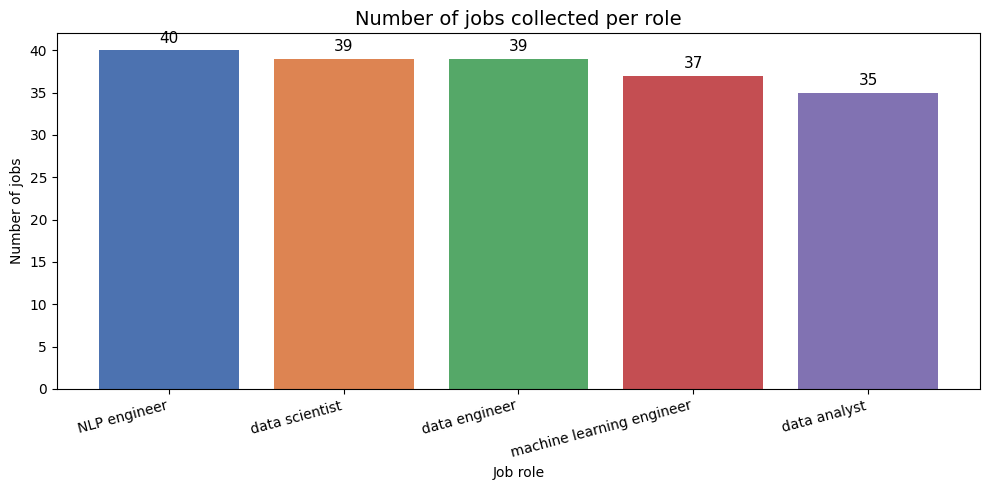

In [4]:
plt.figure(figsize=(10, 5))

# Count jobs per search query
role_counts = jobs_df["search_query"].value_counts()

# Create bar chart
bars = plt.bar(role_counts.index, role_counts.values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])

# Add count labels on top of each bar
for bar, count in zip(bars, role_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha="center", va="bottom", fontsize=11)

plt.title("Number of jobs collected per role", fontsize=14)
plt.xlabel("Job role")
plt.ylabel("Number of jobs")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/cleaned/role_distribution.png", dpi=150)
plt.show()

Remote vs on-site analysis

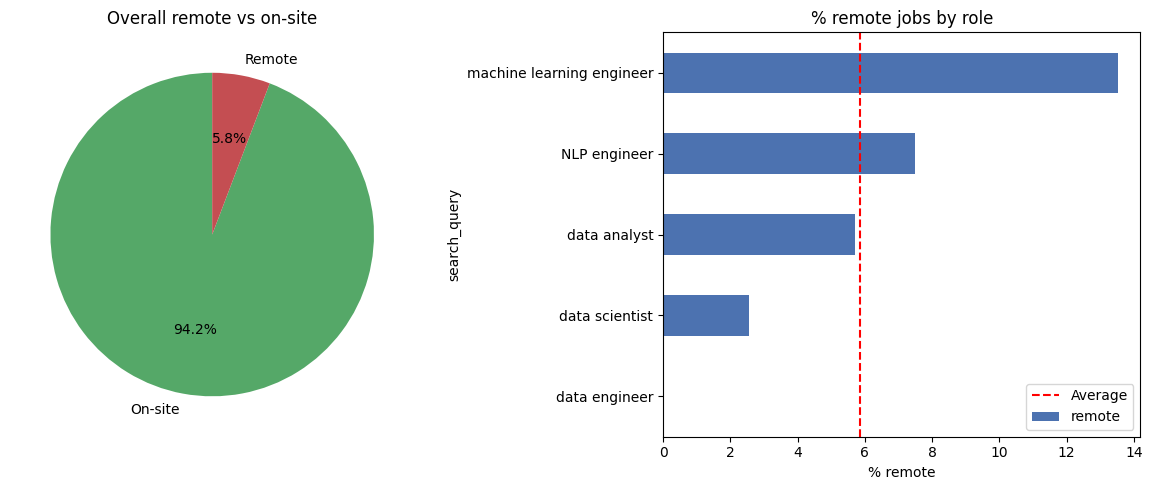

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall remote distribution
remote_counts = jobs_df["remote"].value_counts()
labels = ["On-site", "Remote"] if False in remote_counts.index else ["Remote", "On-site"]
axes[0].pie(remote_counts.values, 
            labels=["Remote" if x else "On-site" for x in remote_counts.index],
            autopct="%1.1f%%",
            colors=["#55A868", "#C44E52"],
            startangle=90)
axes[0].set_title("Overall remote vs on-site")

# Remote by role
remote_by_role = jobs_df.groupby("search_query")["remote"].mean() * 100
remote_by_role.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("% remote jobs by role")
axes[1].set_xlabel("% remote")
axes[1].axvline(x=remote_by_role.mean(), color="red", linestyle="--", label="Average")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("../data/cleaned/remote_analysis.png", dpi=150)
plt.show()

Salary analysis

Jobs with salary data: 49 out of 190 (25.8%)

Salary statistics:
count        49.0
mean     154574.0
std       74416.0
min          52.0
25%      115000.0
50%      142400.0
75%      176500.0
max      550000.0
Name: salary_avg, dtype: float64


<Figure size 1000x600 with 0 Axes>

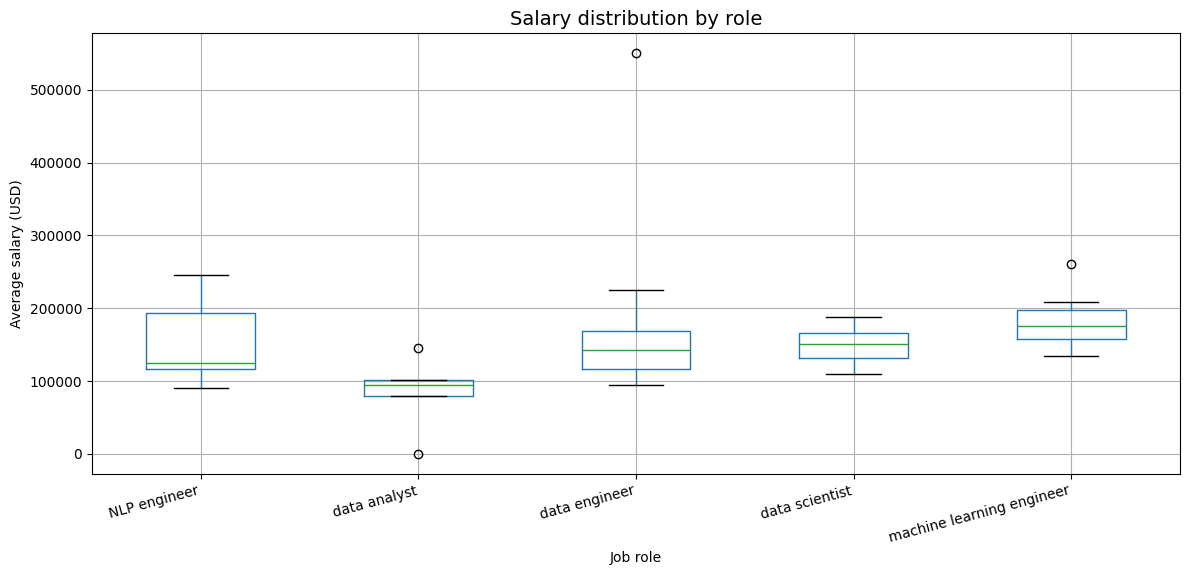

In [7]:
# Filter to only rows that have salary data
salary_df = jobs_df.dropna(subset=["salary_min", "salary_max"])
salary_df = salary_df.copy()

# Create average salary column
salary_df["salary_avg"] = (salary_df["salary_min"] + salary_df["salary_max"]) / 2

print(f"Jobs with salary data: {len(salary_df)} out of {len(jobs_df)} ({len(salary_df)/len(jobs_df)*100:.1f}%)")
print(f"\nSalary statistics:")
print(salary_df["salary_avg"].describe().round(0))

# Plot salary by role
plt.figure(figsize=(10, 6))
salary_df.boxplot(column="salary_avg", by="search_query", figsize=(12, 6))
plt.suptitle("")
plt.title("Salary distribution by role", fontsize=14)
plt.xlabel("Job role")
plt.ylabel("Average salary (USD)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/cleaned/salary_by_role.png", dpi=150)
plt.show()

Top locations

In [10]:
# Dictionary mapping full state names to abbreviations
state_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC",
    "Remote": "Remote"
}

# Extract the part after the comma as the state name
jobs_df["state_full"] = jobs_df["location"].str.extract(r",\s*(.+)$")

# Map full name to abbreviation
jobs_df["state"] = jobs_df["state_full"].map(state_map)

# Check what we got
print("Sample locations and extracted states:")
print(jobs_df[["location", "state_full", "state"]].head(10))
print(f"\nSuccessfully mapped: {jobs_df['state'].notna().sum()} out of {len(jobs_df)} jobs")

Sample locations and extracted states:
                           location            state_full state
0  Washington, District of Columbia  District of Columbia    DC
1  Washington, District of Columbia  District of Columbia    DC
2  Washington, District of Columbia  District of Columbia    DC
3  Washington, District of Columbia  District of Columbia    DC
4              Washington, Virginia              Virginia    VA
5  Washington, District of Columbia  District of Columbia    DC
6                  McLean, Virginia              Virginia    VA
7  Washington, District of Columbia  District of Columbia    DC
8               Arlington, Virginia              Virginia    VA
9                  McLean, Virginia              Virginia    VA

Successfully mapped: 163 out of 190 jobs


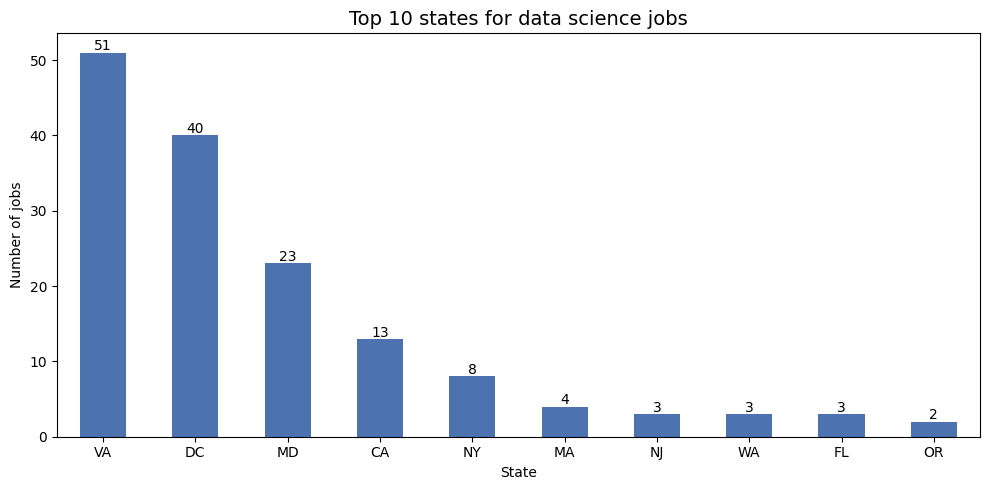


Top 10 states:
state
VA    51
DC    40
MD    23
CA    13
NY     8
MA     4
NJ     3
WA     3
FL     3
OR     2
Name: count, dtype: int64


In [11]:
# Drop unmapped states and plot
top_states = jobs_df["state"].dropna().value_counts().head(10)

plt.figure(figsize=(10, 5))
top_states.plot(kind="bar", color="#4C72B0")
plt.title("Top 10 states for data science jobs", fontsize=14)
plt.xlabel("State")
plt.ylabel("Number of jobs")
plt.xticks(rotation=0)

# Add count labels on top of each bar
for i, (state, count) in enumerate(top_states.items()):
    plt.text(i, count + 0.3, str(count), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/cleaned/top_locations.png", dpi=150)
plt.show()

# Print the actual numbers too
print("\nTop 10 states:")
print(top_states)

In [13]:
# Save the cleaned dataframe with the new state column
jobs_df.to_csv("../data/cleaned/jobs_cleaned.csv", index=False)
print("Cleaned data saved!")

# Print a full summary of everything we learned
print("EDA SUMMARY — KEY FINDINGS")

print(f"\n Total jobs collected: {len(jobs_df)}")
print(f" Job roles: {jobs_df['search_query'].nunique()} different roles")
print(f" Companies: {jobs_df['company'].nunique()} unique companies")

print(f"\n Remote work:")
remote_pct = jobs_df['remote'].mean() * 100
print(f"   {remote_pct:.1f}% of jobs are remote")

print(f"\n Salary data:")
salary_df = jobs_df.dropna(subset=["salary_min", "salary_max"]).copy()
salary_df["salary_avg"] = (salary_df["salary_min"] + salary_df["salary_max"]) / 2
print(f"   {len(salary_df)} jobs have salary data ({len(salary_df)/len(jobs_df)*100:.1f}%)")
if len(salary_df) > 0:
    print(f"   Average salary: ${salary_df['salary_avg'].mean():,.0f}")
    print(f"   Highest avg salary role: {salary_df.groupby('search_query')['salary_avg'].mean().idxmax()}")
    print(f"   Lowest avg salary role:  {salary_df.groupby('search_query')['salary_avg'].mean().idxmin()}")

print(f"\n Top 3 states:")
for state, count in top_states.head(3).items():
    print(f"   {state}: {count} jobs")

print(f"\n DMV region (DC+VA+MD) dominance:")
dmv = top_states[top_states.index.isin(["DC", "VA", "MD"])].sum()
print(f"   {dmv} out of {top_states.sum()} mapped jobs ({dmv/top_states.sum()*100:.1f}%)")



Cleaned data saved!
EDA SUMMARY — KEY FINDINGS

 Total jobs collected: 190
 Job roles: 5 different roles
 Companies: 161 unique companies

 Remote work:
   5.8% of jobs are remote

 Salary data:
   49 jobs have salary data (25.8%)
   Average salary: $154,574
   Highest avg salary role: machine learning engineer
   Lowest avg salary role:  data analyst

 Top 3 states:
   VA: 51 jobs
   DC: 40 jobs
   MD: 23 jobs

 DMV region (DC+VA+MD) dominance:
   114 out of 150 mapped jobs (76.0%)
